<a href="https://colab.research.google.com/github/abhishekanand04/ML-Unsupervised-and-RecSys/blob/unsupervised/MLRS-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
¯import numpy as np

In [ ]:
R = np.array([
    [5, 4, 0, 1, 0, 0, 2],
    [4, 0, 0, 1, 1, 0, 0],
    [1, 1, 0, 5, 0, 0, 4],
    [0, 0, 5, 4, 0, 3, 0],
    [0, 1, 5, 4, 0, 0, 0],
    [0, 0, 4, 0, 5, 4, 0]
], dtype=float)

print("User–Item Rating Matrix (R):")
print(R)


User–Item Rating Matrix (R):
[[5. 4. 0. 1. 0. 0. 2.]
 [4. 0. 0. 1. 1. 0. 0.]
 [1. 1. 0. 5. 0. 0. 4.]
 [0. 0. 5. 4. 0. 3. 0.]
 [0. 1. 5. 4. 0. 0. 0.]
 [0. 0. 4. 0. 5. 4. 0.]]


In [ ]:
np.random.seed(42)

num_users, num_items = R.shape
k = 3  # latent dimensions

U = np.random.rand(num_users, k)
V = np.random.rand(k, num_items)

print("\nInitial User Latent Matrix (U):")
print(U)

print("\nInitial Item Latent Matrix (V):")
print(V)



Initial User Latent Matrix (U):
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643]]

Initial Item Latent Matrix (V):
[[0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184
  0.45606998]
 [0.78517596 0.19967378 0.51423444 0.59241457 0.04645041 0.60754485
  0.17052412]
 [0.06505159 0.94888554 0.96563203 0.80839735 0.30461377 0.09767211
  0.68423303]]


In [ ]:
U.shape

(6, 3)

In [ ]:
V.shape

(3, 7)

In [ ]:
R.shape

(6, 7)

In [ ]:
R

array([[5., 4., 0., 1., 0., 0., 2.],
       [4., 0., 0., 1., 1., 0., 0.],
       [1., 1., 0., 5., 0., 0., 4.],
       [0., 0., 5., 4., 0., 3., 0.],
       [0., 1., 5., 4., 0., 0., 0.],
       [0., 0., 4., 0., 5., 4., 0.]])

In [ ]:
U@V

array([[0.95587613, 0.99348818, 1.42489029, 1.20720501, 0.3765564 ,
        0.78631419, 0.83379066],
       [0.39123733, 0.35352057, 0.59715439, 0.30204246, 0.22966008,
        0.32935026, 0.40637171],
       [0.7442931 , 0.76025765, 1.06141214, 1.00717746, 0.24031097,
        0.60623265, 0.58549686],
       [0.38510505, 1.13065498, 1.38039753, 0.89503888, 0.50326367,
        0.36664992, 0.99008516],
       [0.53812102, 0.45736119, 0.79410054, 0.38890024, 0.30844329,
        0.45173998, 0.54027169],
       [0.3522406 , 0.61209573, 0.77539004, 0.63003305, 0.22756086,
        0.30328729, 0.49458162]])

## Do Stochastic Gradinet descent

In [ ]:
learning_rate = 0.01
epochs = 50


## Ignore the optimisation code

In [ ]:
for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1} ---")

    for i in range(num_users):
        for j in range(num_items):
            if R[i, j] > 0:  # only known ratings

                prediction = np.dot(U[i, :], V[:, j])
                error = R[i, j] - prediction

                print(f"User {i+1}, Movie {j+1}")
                print(" Actual:", R[i, j],
                      " Predicted:", round(prediction, 2),
                      " Error:", round(error, 2))

                # Update rules
                for k_idx in range(k):
                    U[i, k_idx] += learning_rate * error * V[k_idx, j]
                    V[k_idx, j] += learning_rate * error * U[i, k_idx]


--- Epoch 1 ---
User 1, Movie 1
 Actual: 5.0  Predicted: 3.37  Error: 1.63
User 1, Movie 2
 Actual: 4.0  Predicted: 2.06  Error: 1.94
User 1, Movie 4
 Actual: 1.0  Predicted: 3.31  Error: -2.31
User 1, Movie 7
 Actual: 2.0  Predicted: 2.51  Error: -0.51
User 2, Movie 1
 Actual: 4.0  Predicted: 2.34  Error: 1.66
User 2, Movie 4
 Actual: 1.0  Predicted: 1.7  Error: -0.7
User 2, Movie 5
 Actual: 1.0  Predicted: 1.46  Error: -0.46
User 3, Movie 1
 Actual: 1.0  Predicted: 2.74  Error: -1.74
User 3, Movie 2
 Actual: 1.0  Predicted: 2.26  Error: -1.26
User 3, Movie 4
 Actual: 5.0  Predicted: 3.27  Error: 1.73
User 3, Movie 7
 Actual: 4.0  Predicted: 2.58  Error: 1.42
User 4, Movie 3
 Actual: 5.0  Predicted: 4.99  Error: 0.01
User 4, Movie 4
 Actual: 4.0  Predicted: 3.82  Error: 0.18
User 4, Movie 6
 Actual: 3.0  Predicted: 3.0  Error: 0.0
User 5, Movie 2
 Actual: 1.0  Predicted: 2.12  Error: -1.12
User 5, Movie 3
 Actual: 5.0  Predicted: 4.37  Error: 0.63
User 5, Movie 4
 Actual: 4.0  Predic

In [ ]:
R

array([[5., 4., 0., 1., 0., 0., 2.],
       [4., 0., 0., 1., 1., 0., 0.],
       [1., 1., 0., 5., 0., 0., 4.],
       [0., 0., 5., 4., 0., 3., 0.],
       [0., 1., 5., 4., 0., 0., 0.],
       [0., 0., 4., 0., 5., 4., 0.]])

In [ ]:
U@V

array([[5.2536159 , 2.92300526, 2.91039359, 1.41655902, 2.58663464,
        3.25601942, 2.03118617],
       [3.76051755, 1.78887877, 2.05465633, 0.5378694 , 1.56201585,
        2.08191127, 1.02591942],
       [1.01652813, 1.15442189, 3.60071875, 4.85736317, 4.2415525 ,
        2.69347685, 3.92458949],
       [2.96245802, 1.47254462, 4.60663129, 4.18224781, 4.4700929 ,
        3.27267336, 3.59836086],
       [3.66528247, 1.72115249, 4.75268031, 3.86617263, 4.43515737,
        3.46964148, 3.46096652],
       [3.78792222, 2.17873258, 4.62770214, 4.22846423, 4.62224761,
        3.74313918, 3.84966523]])

In [ ]:
¸V

array([[1.68046214e+00, 4.58404553e-01, 1.38411982e+00, 3.16457992e-01,
        9.03674962e-01, 9.14809384e-01, 4.28546834e-01],
       [1.78512350e+00, 1.24252084e+00, 6.34936654e-01, 4.09367510e-01,
        7.14363528e-01, 1.11066730e+00, 6.99992341e-01],
       [1.49548934e-03, 1.69015879e-01, 1.53978505e+00, 2.13328302e+00,
        1.78499643e+00, 9.46159569e-01, 1.61731993e+00]])

In [ ]:
reconstructed_R = U @ V

In [ ]:
reconstructed_R

array([[5.2536159 , 2.92300526, 2.91039359, 1.41655902, 2.58663464,
        3.25601942, 2.03118617],
       [3.76051755, 1.78887877, 2.05465633, 0.5378694 , 1.56201585,
        2.08191127, 1.02591942],
       [1.01652813, 1.15442189, 3.60071875, 4.85736317, 4.2415525 ,
        2.69347685, 3.92458949],
       [2.96245802, 1.47254462, 4.60663129, 4.18224781, 4.4700929 ,
        3.27267336, 3.59836086],
       [3.66528247, 1.72115249, 4.75268031, 3.86617263, 4.43515737,
        3.46964148, 3.46096652],
       [3.78792222, 2.17873258, 4.62770214, 4.22846423, 4.62224761,
        3.74313918, 3.84966523]])

In [ ]:
R

array([[5., 4., 0., 1., 0., 0., 2.],
       [4., 0., 0., 1., 1., 0., 0.],
       [1., 1., 0., 5., 0., 0., 4.],
       [0., 0., 5., 4., 0., 3., 0.],
       [0., 1., 5., 4., 0., 0., 0.],
       [0., 0., 4., 0., 5., 4., 0.]])

In [ ]:
U

array([[ 1.06314463,  1.94207388,  0.13364212],
       [ 1.13771256,  1.03567469, -0.11538103],
       [-0.11716951,  0.67793096,  2.16423206],
       [ 1.22593202,  0.50406061,  1.68188926],
       [ 1.51353624,  0.62721016,  1.46742955],
       [ 1.02348095,  1.15711663,  1.60826741]])

In [ ]:
V

array([[1.68046214e+00, 4.58404553e-01, 1.38411982e+00, 3.16457992e-01,
        9.03674962e-01, 9.14809384e-01, 4.28546834e-01],
       [1.78512350e+00, 1.24252084e+00, 6.34936654e-01, 4.09367510e-01,
        7.14363528e-01, 1.11066730e+00, 6.99992341e-01],
       [1.49548934e-03, 1.69015879e-01, 1.53978505e+00, 2.13328302e+00,
        1.78499643e+00, 9.46159569e-01, 1.61731993e+00]])

In [ ]:
X = np.array([
    [2, 0],
    [0, 1],
    [1, 1],
    [2, 1],
    [3, 2]
], dtype=float)

print("\nData matrix X (n × d):")
print(X)


Data matrix X (n × d):
[[2. 0.]
 [0. 1.]
 [1. 1.]
 [2. 1.]
 [3. 2.]]


In [ ]:
print("\n==============================")
print("STEP 2: MEAN CENTERING")
print("==============================")

mean = np.mean(X, axis=0)

print("\nMean of each feature:")
print(mean)

X_centered = X - mean


STEP 2: MEAN CENTERING

Mean of each feature:
[1.6 1. ]


In [ ]:
X_centered

array([[ 0.4, -1. ],
       [-1.6,  0. ],
       [-0.6,  0. ],
       [ 0.4,  0. ],
       [ 1.4,  1. ]])

In [ ]:
n, d = X.shape

In [ ]:
# Covariance matrix formula
S = (1 / (n - 1)) * X_centered.T @ X_centered
S

array([[1.3 , 0.25],
       [0.25, 0.5 ]])

## Find eigen vlaues and eigen vectiors

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(S)

In [ ]:
np.diag(eigenvalues)

array([[1.37169906, 0.        ],
       [0.        , 0.42830094]])

In [ ]:
eigenvectors

array([[ 0.96124875, -0.27568251],
       [ 0.27568251,  0.96124875]])

In [ ]:
eigenvectors@np.diag(eigenvalues)@eigenvectors.T

array([[1.3 , 0.25],
       [0.25, 0.5 ]])

In [ ]:
S.T

array([[1.3 , 0.25],
       [0.25, 0.5 ]])

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(S)

In [ ]:
eigenvalues

array([1.37169906, 0.42830094])

In [ ]:
eigenvectors

array([[ 0.96124875, -0.27568251],
       [ 0.27568251,  0.96124875]])

## Collaborative Filtering op Movie lens dataset - Kaggle Notebooks

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [ ]:
np.random.seed(42)

# three clusters
X1 = np.random.randn(100, 2) + np.array([0, 0])
X2 = np.random.randn(100, 2) + np.array([5, 5])
X3 = np.random.randn(100, 2) + np.array([0, 5])

X = np.vstack([X1, X2, X3])


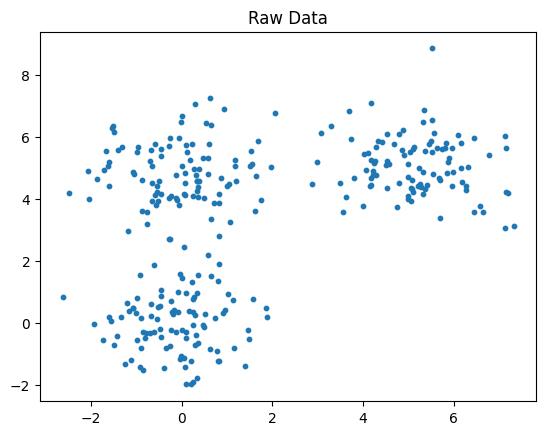

In [ ]:
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Raw Data")
plt.show()


In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_


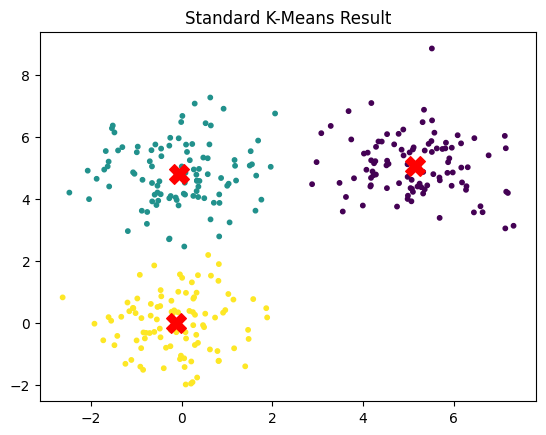

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200)
plt.title("Standard K-Means Result")
plt.show()


In [ ]:
n = X.shape[0]
Z = np.zeros((n, k))

for i, label in enumerate(labels):
    Z[i, label] = 1


In [ ]:
centroids

array([[ 5.14145021,  5.06492727],
       [-0.05910111,  4.80796255],
       [-0.11583672, -0.01817529]])

In [ ]:
Z

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0

In [ ]:
X_reconstructed = Z @ centroids


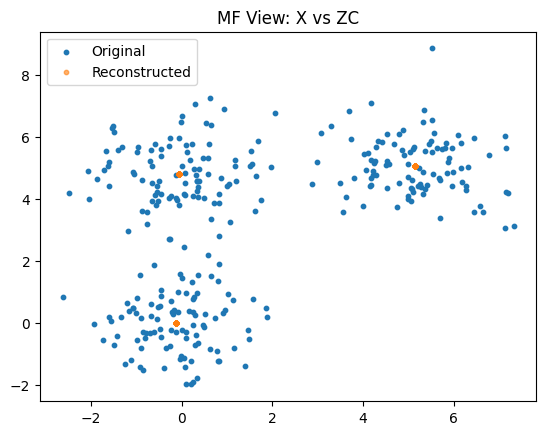

In [ ]:
plt.scatter(X[:, 0], X[:, 1], label="Original", s=10)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            label="Reconstructed", s=10, alpha=0.6)
plt.legend()
plt.title("MF View: X vs ZC")
plt.show()


In [ ]:
mf_loss = np.linalg.norm(X - X_reconstructed, 'fro')**2
mf_loss


np.float64(543.3350760666633)

In [ ]:
kmeans.inertia_


543.3350760666632

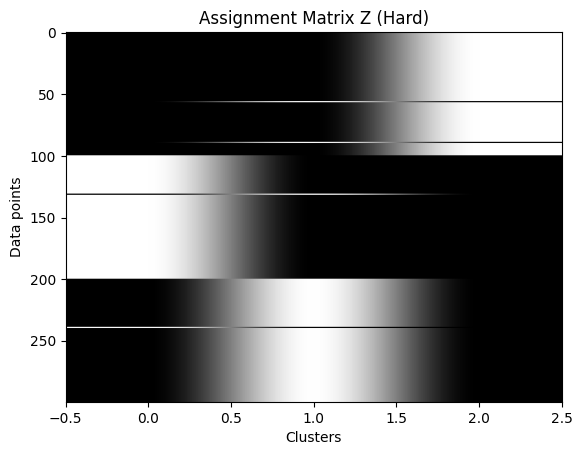

In [ ]:
plt.imshow(Z, aspect='auto', cmap='gray')
plt.xlabel("Clusters")
plt.ylabel("Data points")
plt.title("Assignment Matrix Z (Hard)")
plt.show()


## Initialise Z and C matrix randomly - and then I will try MF with constraints

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X1 = np.random.randn(100, 2) + np.array([0, 0])
X2 = np.random.randn(100, 2) + np.array([5, 5])
X3 = np.random.randn(100, 2) + np.array([0, 5])

X = np.vstack([X1, X2, X3])
n, d = X.shape
k = 3


In [ ]:
Z = np.zeros((n, k))
random_assignments = np.random.choice(k, size=n)

for i, j in enumerate(random_assignments):
    Z[i, j] = 1


In [ ]:
def update_C(X, Z):
    k = Z.shape[1]
    d = X.shape[1]
    C = np.zeros((k, d))

    for j in range(k):
        points = X[Z[:, j] == 1]
        if len(points) > 0:
            C[j] = points.mean(axis=0)
    return C


In [ ]:
def update_Z(X, C):
    n = X.shape[0]
    k = C.shape[0]
    Z = np.zeros((n, k))

    for i in range(n):
        distances = np.linalg.norm(X[i] - C, axis=1)
        j = np.argmin(distances)
        Z[i, j] = 1
    return Z


In [ ]:
losses = []

for it in range(10):
    C = update_C(X, Z)
    Z = update_Z(X, C)

    X_hat = Z @ C
    loss = np.linalg.norm(X - X_hat, 'fro')**2¸
    losses.append(loss)


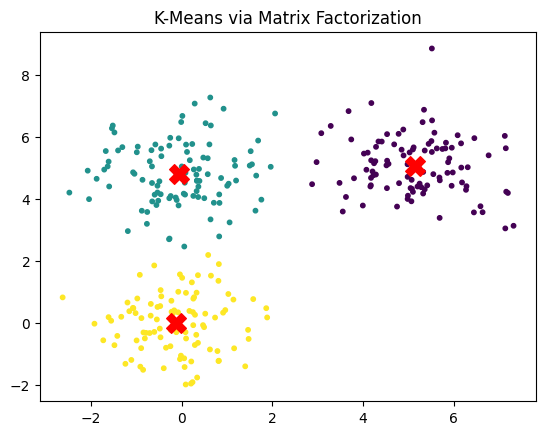

In [ ]:
labels = np.argmax(Z, axis=1)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=10)
plt.scatter(C[:, 0], C[:, 1], c='red', s=200, marker='X')
plt.title("K-Means via Matrix Factorization")
plt.show()


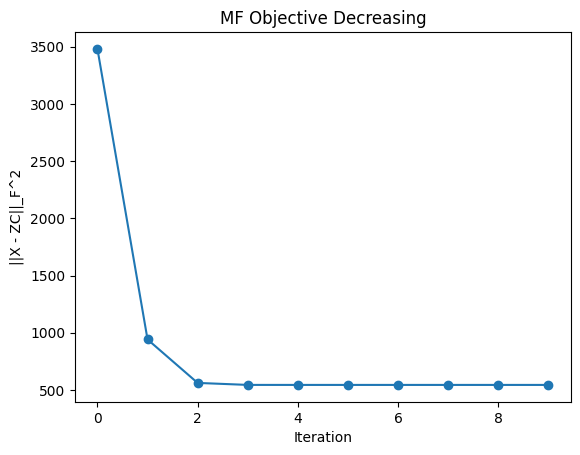

In [ ]:
plt.plot(losses, marker='o')
plt.xlabel("Iteration")
plt.ylabel("||X - ZC||_F^2")
plt.title("MF Objective Decreasing")
plt.show()


In [ ]:
kmeans_.inertia

NameError: name 'kmeans_' is not defined